Sales Prediction using Python



In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving archive (3).zip to archive (3).zip
User uploaded file "archive (3).zip" with length 2316 bytes


In [ ]:
import zipfile

# Assuming 'Advertising.csv' is inside 'archive (3).zip'
with zipfile.ZipFile('archive (3).zip', 'r') as zip_ref:
    zip_ref.extractall('.') # Extract to the current directory

data = pd.read_csv('Advertising.csv')

In [ ]:
df = pd.read_csv("Advertising.csv")

In [ ]:
print(df.head())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


Check Dataset Information

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [ ]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


Remove Unnecessary Column

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


Visualize Data

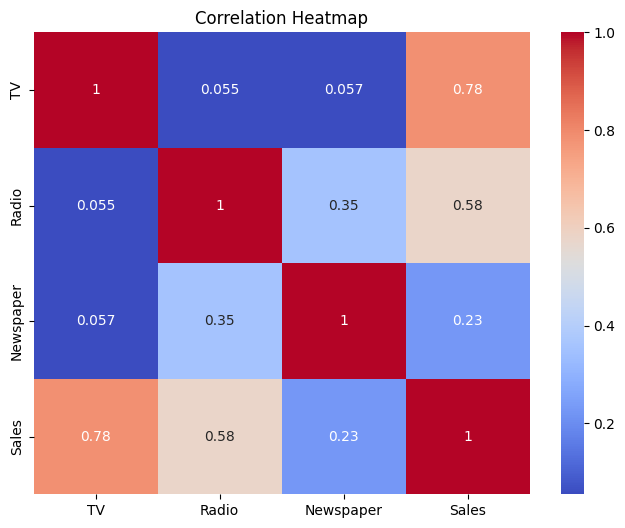

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Select Input and Output

In [ ]:
X = df[['TV', 'Radio', 'Newspaper']]

In [ ]:
y = df['Sales']

Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Create and Train Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predict Sales

In [ ]:
y_pred = model.predict(X_test)

Check Accuracy

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.4607567168117603
MSE: 3.1740973539761033
R2 Score: 0.899438024100912


Compare Actual vs Predicted Sales

In [ ]:
comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

print(comparison.head())

     Actual Sales  Predicted Sales
95           16.9        16.408024
15           22.4        20.889882
30           21.4        21.553843
158           7.3        10.608503
128          24.7        22.112373


Visualization of Prediction

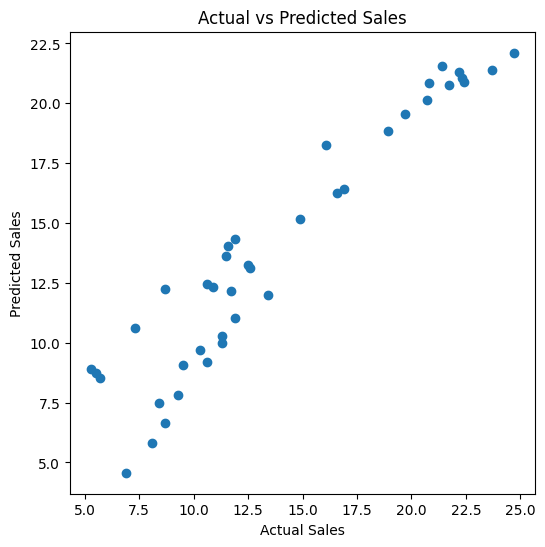

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

Predict Custom Values

In [ ]:
tv = 200
radio = 40
newspaper = 50

prediction = model.predict([[tv, radio, newspaper]])

print("Predicted Sales:", prediction[0])

Predicted Sales: 19.630828718309314


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


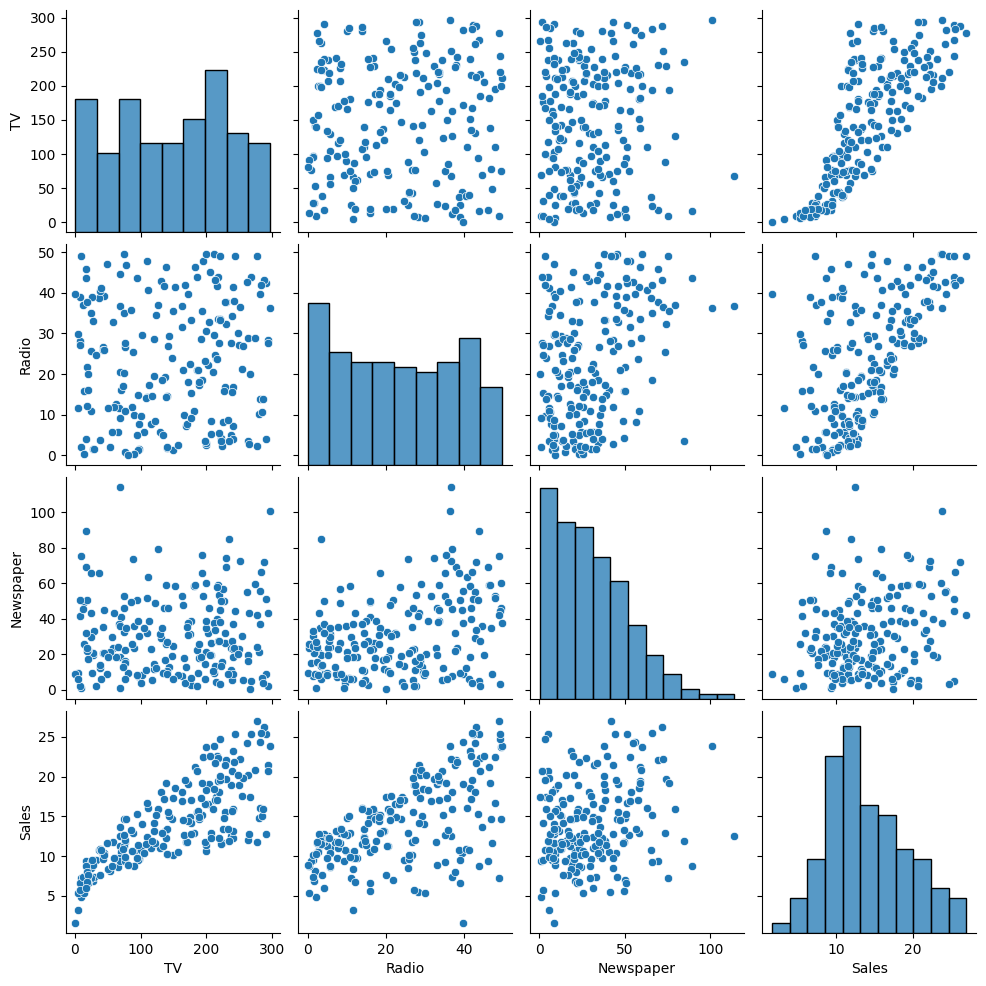

In [ ]:
sns.pairplot(df)
plt.show()

Sales Distribution

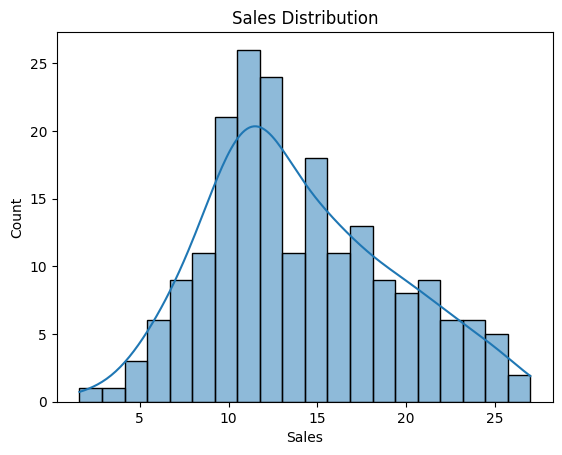

In [ ]:
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title("Sales Distribution")
plt.show()

TV vs Sales

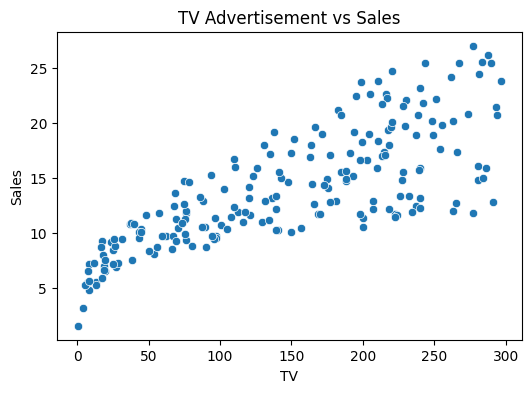

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertisement vs Sales")
plt.show()

Add Model Accuracy Percentage

In [ ]:
accuracy = r2_score(y_test, y_pred) * 100
print("Accuracy:", accuracy, "%")

Accuracy: 89.9438024100912 %


Add User Input Prediction

In [ ]:
tv = float(input("Enter TV advertising amount: "))
radio = float(input("Enter Radio advertising amount: "))
newspaper = float(input("Enter Newspaper advertising amount: "))

prediction = model.predict([[tv, radio, newspaper]])

print("Predicted Sales:", prediction[0])

Enter TV advertising amount: 50000
Enter Radio advertising amount: 20000
Enter Newspaper advertising amount: 10000
Predicted Sales: 6050.967168875141


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Add Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(importance)

     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


Add Regression Line Plot

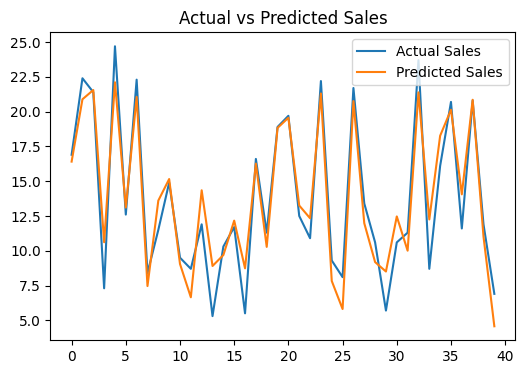

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(y_test.values, label='Actual Sales')
plt.plot(y_pred, label='Predicted Sales')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

Multiple Algorithms

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(r2_score(y_test, rf_pred))

0.98442463320578


Conclusion

The Linear Regression model successfully predicts sales based on advertisement spending. TV advertising contributes the most to sales prediction. The model achieved high accuracy with a strong R² score.